## Before you try to run this script, make sure you do the following:

- You need to log in to your Hugging Face account and create **an access token** to log in from Colab or Kaggle. - Next, find SAM 3 on Hugging Face and request access to it. Once your request is approved, run the following code snippet in Colab or Kaggle:
 
    - *from huggingface_hub import login*
    
    - *login(token="YOUR_ACCESS_TOKEN")*
 
  - Also, after installing the older version of NumPy (1.26.4) and huggingface_hub, you must click Run --> Restart session (or Restart and clear cell outputs). The environment needs to clear its active memory cache before it can properly load the newly installed libraries.
 
## Image segmentation with SAM 3

This notebook demonstrates how to use SAM 3 for image segmentation with text prompts.

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")


In [ ]:
!pip install torch==2.14.0
!pip install torchvision==0.29.0

In [ ]:
!pip install --force-reinstall --no-cache-dir "numpy>=1.26,<2" pandas scipy scikit-learn

In [ ]:
import torch
import torchvision
import numpy
print(torchvision.__version__)
print(numpy.__version__)

In [ ]:
#!{sys.executable} -m pip install -U "numpy>=2.1"
import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install triton
!{sys.executable} -m pip install opencv-python matplotlib scikit-learn
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [5]:
import os

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3 import build_sam3_image_model
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.dirname(sam3.__file__)

/usr/local/lib/python3.12/dist-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/usr/local/lib/python3.12/dist-packages/sam3/model/model_misc.py:71: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
!python -c "import numpy as np; print(np.__version__); print(np.__file__)"

In [11]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# **HuggingFace authentication**

In [ ]:
!pip install --upgrade huggingface_hub

In [6]:
#!hf auth whoami
#!hf auth login
from huggingface_hub import login
login(token="YOUR_ACCESS_TOKEN") # please create and use yours

# Build Model

In [7]:
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
print(bpe_path)
#!ls -l

/usr/local/lib/python3.12/dist-packages/sam3/assets/bpe_simple_vocab_16e6.txt.gz


In [8]:
#bpe_path = "/usr/local/lib/python3.13/dist-packages/sam3/ass
bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

In [12]:
#image_path = f"{sam3_root}/assets/images/test_image.jpg"
image_index     = 0
root_dir        = "/kaggle/input/datasets/mdreza1/random-images/"
image_list      = ["random_dog2.jpg", "dogs_and_human.jpg"]
text_prompt     = ["dog", "dog, human"]
image_path      = f"{root_dir}/{image_list[image_index]}"

image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)

# Text prompt

Output keys: dict_keys(['original_height', 'original_width', 'backbone_out', 'geometric_prompt', 'masks_logits', 'masks', 'boxes', 'scores'])
Masks shape: torch.Size([1, 1, 400, 600])
Boxes shape: torch.Size([1, 4])
Scores: tensor([0.9258], device='cuda:0', dtype=torch.bfloat16)
found 1 object(s)


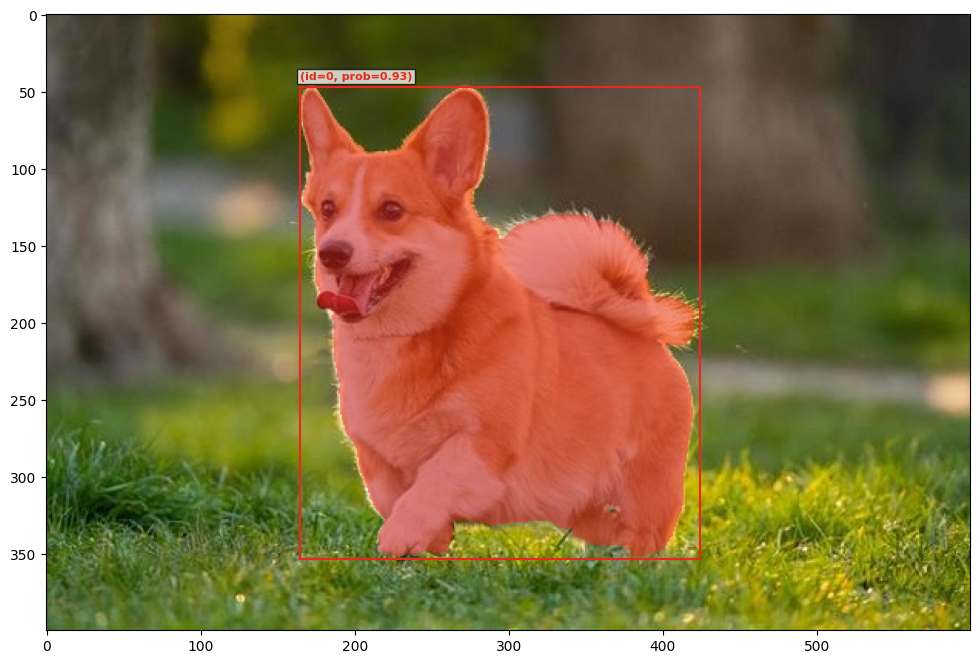

In [13]:
#processor.reset_all_prompts(inference_state)
#inference_state = processor.set_text_prompt(state=inference_state, prompt="dog")

output = processor.set_text_prompt(
    state=inference_state,
    prompt=text_prompt[image_index]
)


print("Output keys:", output.keys())
print("Masks shape:", output["masks"].shape)
print("Boxes shape:", output["boxes"].shape)
print("Scores:", output["scores"])        

img0 = Image.open(image_path)
plot_results(img0, inference_state)
